# Final Individual Project - ANOVA using YRBS 2007

## Topic
**The Relationship Between Physical Activity and BMI Percentile Among Students**

## Research Question
Do students who meet the recommended level of physical activity have different BMI percentiles than those who do not?

## 1. Import Libraries
This project uses `pandas` for data handling, `matplotlib` for visualization, and `statsmodels` / `scipy` for statistical inference.

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)

## 2. Load Data
The original dataset is `YRBS_2007.csv`.

In [11]:
DATA_PATH = '../data/raw/YRBS_2007.csv'
df = pd.read_csv(DATA_PATH)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (14041, 103)


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,RidingWithADrinkingDriver,DrinkingAndDriving,WeaponCarrying,GunCarryingPast12Mos,WeaponCarryingAtSchool,SafetyConcernsAtSchool,WereThreatenedOrInjuredWithAWeaponOnSchoolProperty,StolenOrDamagedYourProperty,PhysicalFighting,InjuredIFight,PhysicalFightingAtSchool,BoyfriendGirlfriendPhysicallyHurt,ForcedSexualIntercourse,SadOrHopeless,ConsideredSuicide,MadeASuicidePlan,AttemptedSuicide,InjuriousSuicide,EverCigaretteUse,InitiationSmokingWholeCigarette,CurrentCigaretteUse,SmokedMoreThan10Cigarettes,HowObtainedCigarettes,SmokeOnSchoolProperty,EverSmokedDailyFor30Days,EverSmokingCessation,CurrentSmokelessTobaccoUse,CurrentSmokelessTobaccoOnSchoolProperty,CurrentCigarUse,EverAlcoholUse,InitiationOfAlcoholUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,SourceOfAlcohol,DrinkAlcoholOnSchoolProperty,EverMarijuaUse,InitiationOfMarijuaUse,CurrentMarijuaUse,MarijuaOnSchoolProperty,EverCocaineUse,CocaineUsePast30Days,EverInhalantUse,EverHeroinUse,EverMethamphetamineUse,EverEcstasyUse,EverSteriodUse,IllegalInjectedDrugUse,IllegalDrugsAtSchool,EverSexualIntercourse,FirstSexualIntercourse,MultipleSexPartners,CurrentSexualActivity,AlcoholDrugsAndSex,CondomUse,BirthControlPillUse,PerceptionOfWeight,WeightLoss,ExerciseToLoseWeight,ConsumeFewerCaloriesToLoseWeight,FastingToLoseWeight,DietPillsToLoseWeight,LaxativesToLoseWeight,FruitJuiceDrinking,FruitEating,GreenSaladEating,PotatoEating,CarrotEating,OtherVegetableEating,NoSodaDrinking,NoMilkDrinking,PhysicalActivity5OrMoreDays,TelevisionWatching,ComputerUse,PEAttendance,SportsTeamParticipation,TaughtAboutHIV,Asthma,StillHaveAsthma,UsedMotorcycleHelmet,EverUsedLSD,AerobicExercise,NoerobicExercise,MinutesInPEPlayingSports,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,5.0,5.0,4.0,3.0,1.0,5.0,6.0,3.0,8.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,7.0,7.0,2.0,3.0,1.0,3.0,5.0,4.0,4.0,NaN,2.0,NaN,4.0,5.0,3.0,NaN,2.0,NaN,NaN,5.0,2.0,4.0,6.0,4.0,4.0,3.0,1.0,2.0,1.0,6.0,5.0,4.0,2.0,3.0,2.0,3.0,3.0,1.0,1.0,2.0,2.0,2.0,5.0,5.0,3.0,2.0,1.0,1.0,7.0,5.0,5.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,2.0,2.0,6.0,8.0,1.0,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,4.0,NaN,NaN,NaN,NaN,2.0,2.0,7.0,7.0,4.0,4.0,7.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,7.0,7.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,2.0,2.0,2.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,6.0,3.0,2.0,2.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,1.0,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,4.0,5.0,4.0,3.0,4.0,2.0,2.0,1.0,2.0,2.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,4.0,4.0,NaN,2.0,2.0,NaN,NaN,6.0,NaN,2.0,2.0,1.0,5.0,5.0,4.0,2.0,4.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,2.0,2.0,1.0,1.0,2.0,4.0,4.0,2.0,2.0,4.0,2.0,2.0,1.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,2.0,NaN,3.0,2.0,4.0,4.0,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,5.0,NaN,5.0,5.0,5.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,3.0,7.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,N

## 3. Select Variables

### Explanatory Variable
`PhysicalActivity5OrMoreDays`: number of days the student was physically active for at least 60 minutes during the past seven days.

The project recodes this into `QN80_group`:
- **Met recommendation**: 5 or more days
- **Did not meet recommendation**: fewer than 5 days

### Response Variable
`BMIPCT`: BMI percentile.

In [12]:
selected = df[['PhysicalActivity5OrMoreDays', 'BMIPCT']].copy()
selected.head()

,PhysicalActivity5OrMoreDays,BMIPCT
0,5.0,NaN
1,2.0,66.531824
2,3.0,NaN
3,1.0,98.174319
4,NaN,NaN


## 4. Raw Data Check
Before cleaning, check missing values and the original coding of the variables.

In [13]:
print(selected.isna().sum())
print('PhysicalActivity5OrMoreDays value counts:')
print(selected['PhysicalActivity5OrMoreDays'].value_counts(dropna=False).sort_index())
print('BMIPCT summary:')
print(selected['BMIPCT'].describe())

PhysicalActivity5OrMoreDays    201
BMIPCT                         979
dtype: int64
PhysicalActivity5OrMoreDays value counts:
PhysicalActivity5OrMoreDays
1.0    3640
2.0    1447
3.0    1503
4.0    1487
5.0    1132
6.0    1538
7.0     816
8.0    2277
NaN     201
Name: count, dtype: int64
BMIPCT summary:
count    1.306200e+04
mean     6.482068e+01
std      2.751676e+01
min      3.720000e-09
25%      4.516627e+01
50%      7.013853e+01
75%      8.945097e+01
max      9.993921e+01
Name: BMIPCT, dtype: float64


## 5. Data Cleaning and Recoding
The activity variable is coded from 1 to 8, representing 0 to 7 days. Therefore, `activity_days = PhysicalActivity5OrMoreDays - 1`.

Students with `activity_days >= 5` are classified as meeting the physical activity recommendation.

In [14]:
clean = selected.dropna().copy()
clean['activity_days'] = clean['PhysicalActivity5OrMoreDays'] - 1
clean['QN80_group'] = np.where(
    clean['activity_days'] >= 5,
    'Met recommendation',
    'Did not meet recommendation'
)

clean = clean[['PhysicalActivity5OrMoreDays', 'activity_days', 'QN80_group', 'BMIPCT']]

os.makedirs('../data/processed', exist_ok=True)
clean.to_csv('../data/processed/clean_data.csv', index=False)

print('Clean data shape:', clean.shape)
clean.head()

Clean data shape: (12894, 4)


,PhysicalActivity5OrMoreDays,activity_days,QN80_group,BMIPCT
1,2.0,1.0,Did not meet recommendation,66.531824
3,1.0,0.0,Did not meet recommendation,98.174319
5,1.0,0.0,Did not meet recommendation,33.075531
6,7.0,6.0,Met recommendation,45.688334
7,6.0,5.0,Met recommendation,62.390331


## 6. Descriptive Statistics
This table summarizes the sample size, mean, standard deviation, median, minimum, and maximum BMI percentile for each physical activity group.

In [15]:
summary = clean.groupby('QN80_group')['BMIPCT'].agg(
    n='count',
    mean='mean',
    sd='std',
    median='median',
    min='min',
    max='max'
).reset_index()

os.makedirs('../outputs/tables', exist_ok=True)
summary.to_csv('../outputs/tables/descriptive_statistics.csv', index=False)
summary

,QN80_group,n,mean,sd,median,min,max
0,Did not meet recommendation,8517,65.095591,27.991150,70.797079,3.720000e-09,99.939213
1,Met recommendation,4377,64.382867,26.489254,68.855230,1.930000e-07,99.881219


## 7. Visualization
The bar chart compares group means, while the boxplot shows the distribution of BMI percentile in each group.

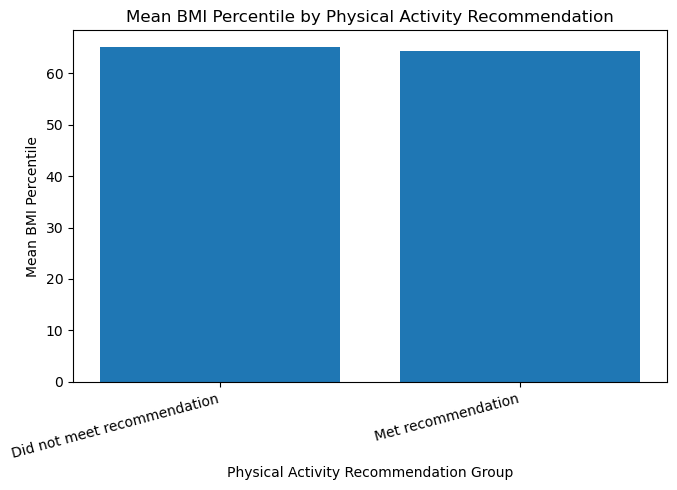

In [16]:
os.makedirs('../outputs/figures', exist_ok=True)

order = ['Did not meet recommendation', 'Met recommendation']
summary_plot = summary.set_index('QN80_group').loc[order]

plt.figure(figsize=(7, 5))
plt.bar(summary_plot.index, summary_plot['mean'])
plt.ylabel('Mean BMI Percentile')
plt.xlabel('Physical Activity Recommendation Group')
plt.title('Mean BMI Percentile by Physical Activity Recommendation')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/figure1_barplot_mean_bmipct.png', dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8704\2343949889.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=order)


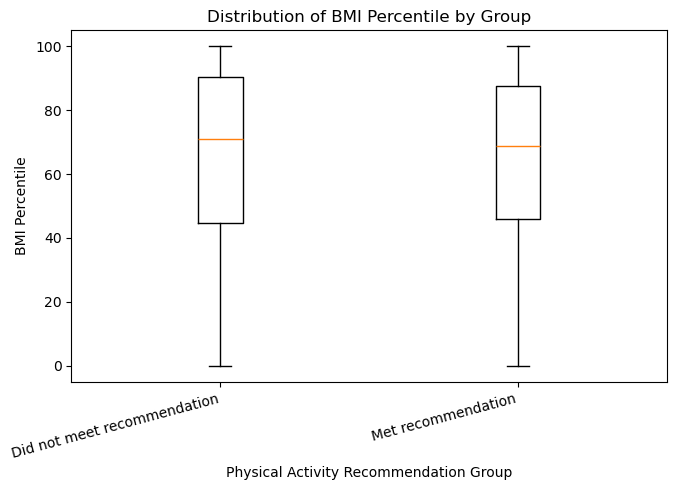

In [17]:
plt.figure(figsize=(7, 5))
box_data = [clean.loc[clean['QN80_group'] == group, 'BMIPCT'] for group in order]
plt.boxplot(box_data, labels=order)
plt.ylabel('BMI Percentile')
plt.xlabel('Physical Activity Recommendation Group')
plt.title('Distribution of BMI Percentile by Group')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/figure2_boxplot_bmipct_by_group.png', dpi=300)
plt.show()

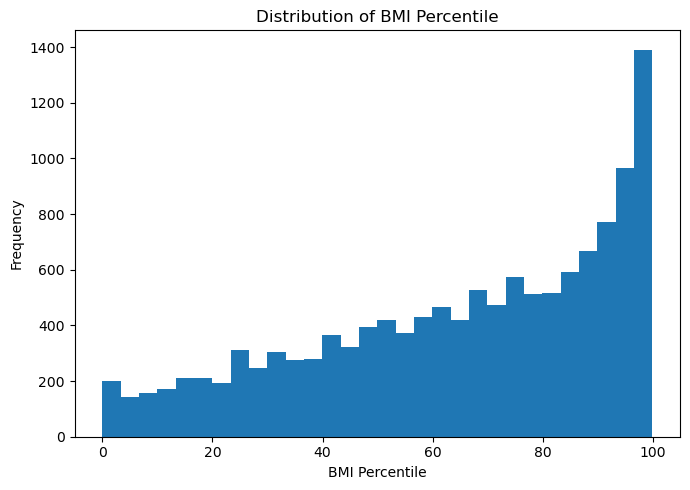

In [18]:
plt.figure(figsize=(7, 5))
plt.hist(clean['BMIPCT'], bins=30)
plt.xlabel('BMI Percentile')
plt.ylabel('Frequency')
plt.title('Distribution of BMI Percentile')
plt.tight_layout()
plt.savefig('../outputs/figures/figure3_histogram_bmipct.png', dpi=300)
plt.show()

## 8. One-Way ANOVA

### Hypotheses

**Null hypothesis (H0):** The mean BMI percentile is the same for students who met and did not meet the physical activity recommendation.

**Alternative hypothesis (H1):** The mean BMI percentile is different between the two groups.

In [19]:
model = smf.ols('BMIPCT ~ C(QN80_group)', data=clean).fit()
anova_table = sm.stats.anova_lm(model, typ=2).reset_index().rename(columns={'index': 'Source', 'PR(>F)': 'p_value'})

anova_table.to_csv('../outputs/tables/anova_table.csv', index=False)
anova_table

,Source,sum_sq,df,F,p_value
0,C(QN80_group),1.468649e+03,1.0,1.943351,0.163329
1,Residual,9.742878e+06,12892.0,NaN,NaN


## 9. 95% Confidence Interval for the Difference in Means
The difference is calculated as:

**Met recommendation - Did not meet recommendation**

In [20]:
met = clean.loc[clean['QN80_group'] == 'Met recommendation', 'BMIPCT']
not_met = clean.loc[clean['QN80_group'] == 'Did not meet recommendation', 'BMIPCT']

n1, n0 = len(met), len(not_met)
m1, m0 = met.mean(), not_met.mean()
s1, s0 = met.std(ddof=1), not_met.std(ddof=1)

mean_diff = m1 - m0
se_diff = np.sqrt((s1**2 / n1) + (s0**2 / n0))
welch_df = (s1**2 / n1 + s0**2 / n0)**2 / (((s1**2 / n1)**2 / (n1 - 1)) + ((s0**2 / n0)**2 / (n0 - 1)))
ci_low, ci_high = stats.t.interval(0.95, welch_df, loc=mean_diff, scale=se_diff)

ci_table = pd.DataFrame({
    'comparison': ['Met recommendation - Did not meet recommendation'],
    'difference_in_means': [mean_diff],
    'ci_lower': [ci_low],
    'ci_upper': [ci_high],
    'welch_df': [welch_df]
})

ci_table.to_csv('../outputs/tables/mean_difference_ci.csv', index=False)
ci_table

,comparison,difference_in_means,ci_lower,ci_upper,welch_df
0,Met recommendation - Did not meet recommendation,-0.712724,-1.69734,0.271892,9270.578543


## 10. Assumption Checking
ANOVA assumes independent observations, roughly normal residuals within groups, and similar variance across groups. With a large sample size, ANOVA is generally robust, but residual plots and Levene's test are still useful checks.

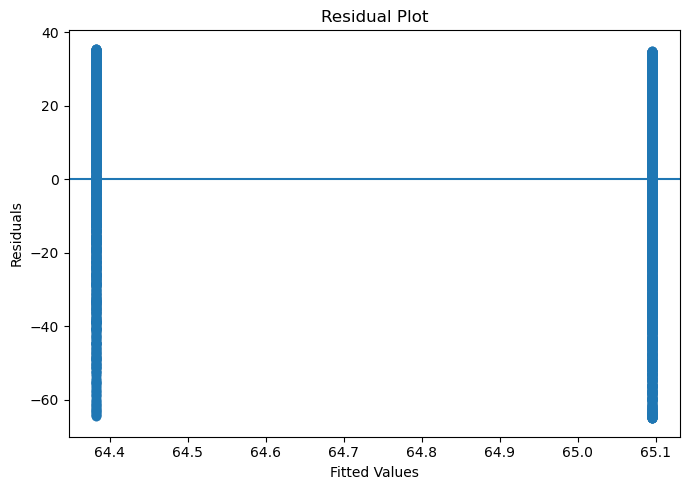

In [21]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(7, 5))
plt.scatter(fitted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('../outputs/figures/figure4_residual_plot.png', dpi=300)
plt.show()

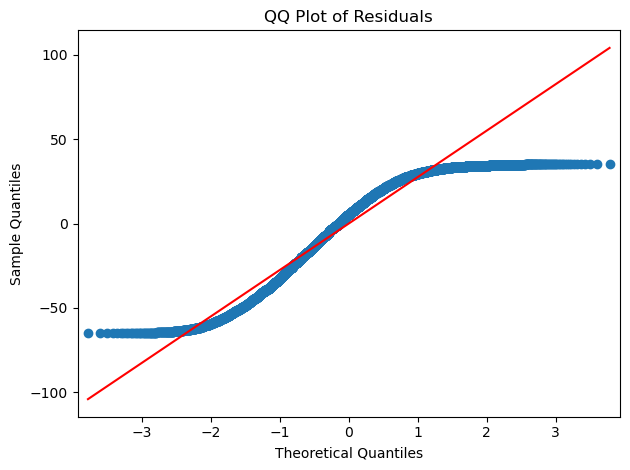

In [22]:
fig = sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.tight_layout()
plt.savefig('../outputs/figures/figure5_qq_plot.png', dpi=300)
plt.show()

In [23]:
levene_stat, levene_p = stats.levene(met, not_met)
print('Levene test statistic:', round(levene_stat, 4))
print('Levene p-value:', round(levene_p, 4))

Levene test statistic: 24.1427
Levene p-value: 0.0


## 11. Interpretation
Use the following cell to print a short interpretation based on the ANOVA p-value.

In [24]:
f_value = anova_table.loc[0, 'F']
p_value = anova_table.loc[0, 'p_value']

print(f'Analytic sample size: n = {len(clean):,}')
print(f'Mean BMI percentile, met recommendation: {m1:.2f}')
print(f'Mean BMI percentile, did not meet recommendation: {m0:.2f}')
print(f'Difference in means: {mean_diff:.2f}')
print(f'F statistic: {f_value:.3f}')
print(f'p-value: {p_value:.3f}')
print(f'95% CI for difference in means: [{ci_low:.2f}, {ci_high:.2f}]')

if p_value < 0.05:
    print('Conclusion: Reject H0. There is a statistically significant difference in mean BMI percentile between the two groups.')
else:
    print('Conclusion: Fail to reject H0. There is not enough evidence to conclude that the mean BMI percentile differs between the two groups.')

Analytic sample size: n = 12,894
Mean BMI percentile, met recommendation: 64.38
Mean BMI percentile, did not meet recommendation: 65.10
Difference in means: -0.71
F statistic: 1.943
p-value: 0.163
95% CI for difference in means: [-1.70, 0.27]
Conclusion: Fail to reject H0. There is not enough evidence to conclude that the mean BMI percentile differs between the two groups.


## 12. Final Conclusion
The analysis compares BMI percentile between students who met and did not meet the physical activity recommendation. In this dataset, students who met the recommendation had a slightly lower mean BMI percentile, but the one-way ANOVA result was not statistically significant at alpha = 0.05.

Because the YRBS data are observational and self-reported, this result should be interpreted as an association rather than a causal relationship.